In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/credit_risk_cleaned.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (32407, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [3]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

numerical_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

print("Number of features:", X.shape[1])
print("Target distribution:")
print(y.value_counts())

Number of features: 11
Target distribution:
loan_status
0    25319
1     7088
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25925
Testing samples: 6482


In [5]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

print("Models ready:")
for model in models:
    print("-", model)

Models ready:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost


In [7]:
results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost,0.933971,0.964353,0.724965,0.827697,0.938210,0.890713
1,Random Forest,0.935205,0.973435,0.723554,0.830097,0.934023,0.889260
2,Gradient Boosting,0.925023,0.936330,0.705219,0.804505,0.926807,0.873783
3,Logistic Regression,0.806541,0.539922,0.782087,0.638825,0.871618,0.706438


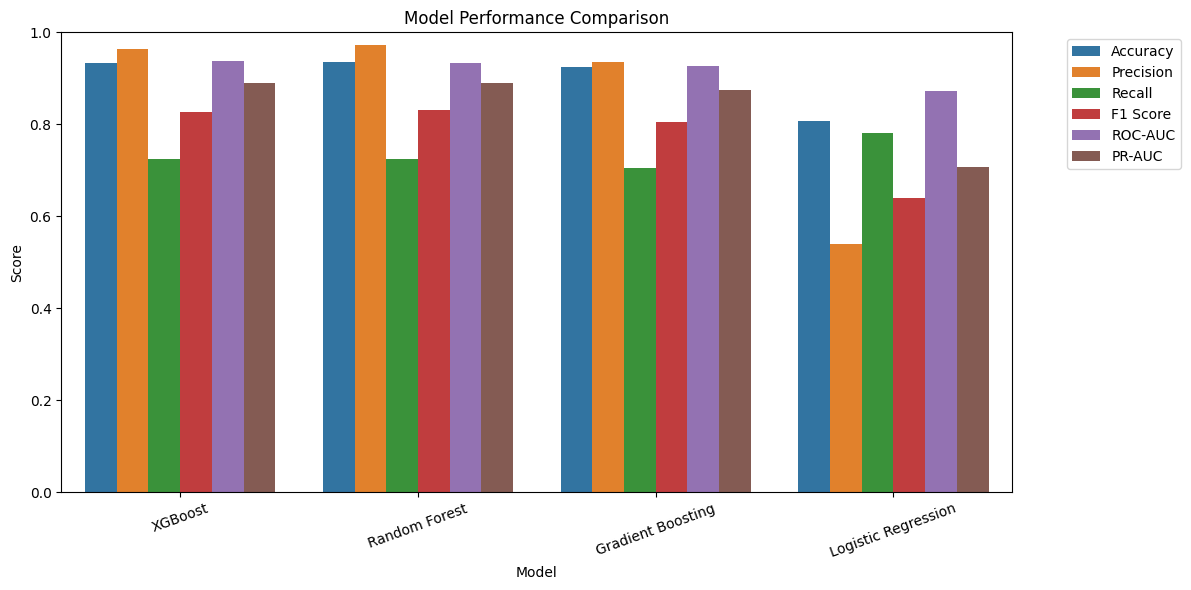

In [8]:
plt.figure(figsize=(12, 6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

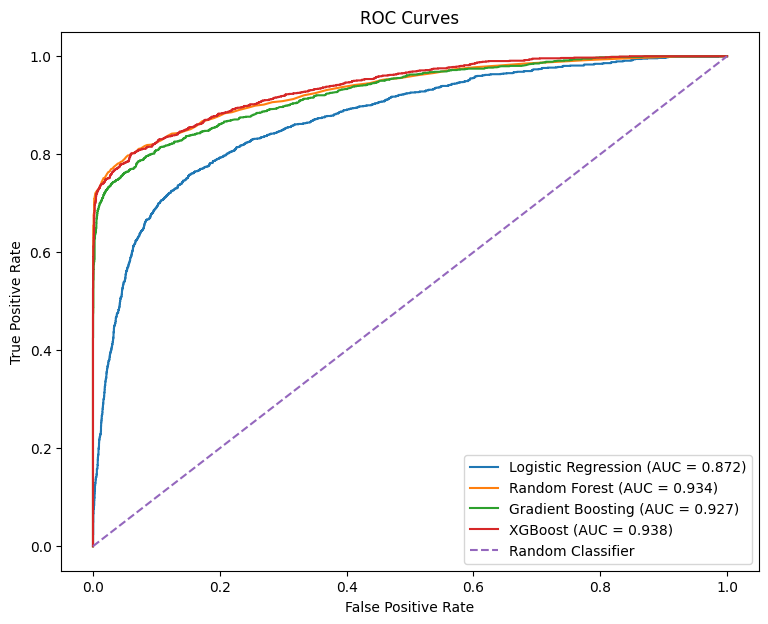

In [9]:
plt.figure(figsize=(9, 7))

for name, model in trained_models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

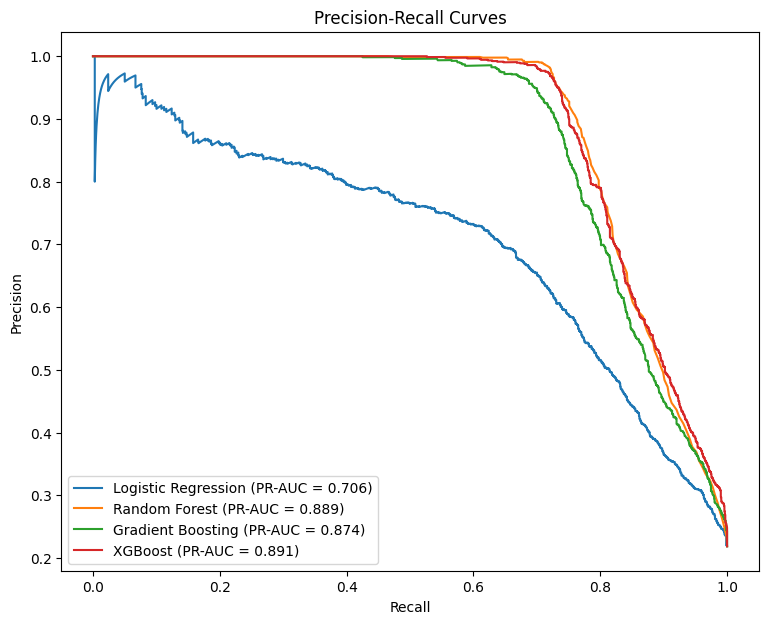

In [10]:
plt.figure(figsize=(9, 7))

for name, model in trained_models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (PR-AUC = {pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

In [11]:
for name, model in trained_models.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    y_pred = model.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Non-Default",
                "Default"
            ]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

 Non-Default       0.93      0.81      0.87      5064
     Default       0.54      0.78      0.64      1418

    accuracy                           0.81      6482
   macro avg       0.74      0.80      0.75      6482
weighted avg       0.84      0.81      0.82      6482

Random Forest
              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      5064
     Default       0.97      0.72      0.83      1418

    accuracy                           0.94      6482
   macro avg       0.95      0.86      0.90      6482
weighted avg       0.94      0.94      0.93      6482

Gradient Boosting
              precision    recall  f1-score   support

 Non-Default       0.92      0.99      0.95      5064
     Default       0.94      0.71      0.80      1418

    accuracy                           0.93      6482
   macro avg       0.93      0.85      0.88      6482
weighted avg       0.9

In [12]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model based on ROC-AUC:")
print(best_model_name)

Best model based on ROC-AUC:
XGBoost


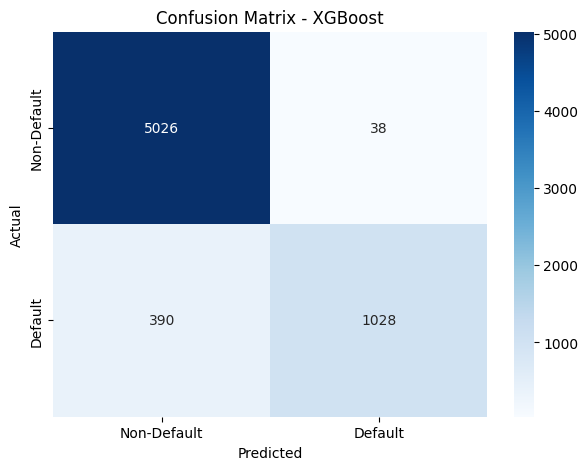

In [13]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Default", "Default"],
    yticklabels=["Non-Default", "Default"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

In [14]:
if best_model_name == "Logistic Regression":

    base_model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    param_grid = {
        "model__C": [0.1, 1, 10],
        "model__solver": ["liblinear", "lbfgs"]
    }

elif best_model_name == "Random Forest":

    base_model = RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5]
    }

elif best_model_name == "Gradient Boosting":

    base_model = GradientBoostingClassifier(
        random_state=42
    )

    param_grid = {
        "model__n_estimators": [100, 150],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    }

else:

    base_model = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

    param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 4],
        "model__learning_rate": [0.05, 0.1]
    }

print("Model selected for tuning:", best_model_name)
print("Parameter grid:")
print(param_grid)

Model selected for tuning: XGBoost
Parameter grid:
{'model__n_estimators': [100, 200], 'model__max_depth': [3, 4], 'model__learning_rate': [0.05, 0.1]}


In [15]:
tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", base_model)
    ]
)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}

Best cross-validation ROC-AUC:
0.9405898593643863


In [16]:
tuned_model = grid_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test)
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

tuned_results = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1 Score": f1_score(y_test, y_pred_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_prob_tuned),
    "PR-AUC": average_precision_score(y_test, y_prob_tuned)
}

print("TUNED MODEL PERFORMANCE")
print("=" * 40)

for metric, value in tuned_results.items():
    print(f"{metric}: {value:.4f}")

TUNED MODEL PERFORMANCE
Accuracy: 0.9371
Precision: 0.9720
Recall: 0.7334
F1 Score: 0.8360
ROC-AUC: 0.9470
PR-AUC: 0.9031


In [17]:
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=[
            "Non-Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      5064
     Default       0.97      0.73      0.84      1418

    accuracy                           0.94      6482
   macro avg       0.95      0.86      0.90      6482
weighted avg       0.94      0.94      0.93      6482



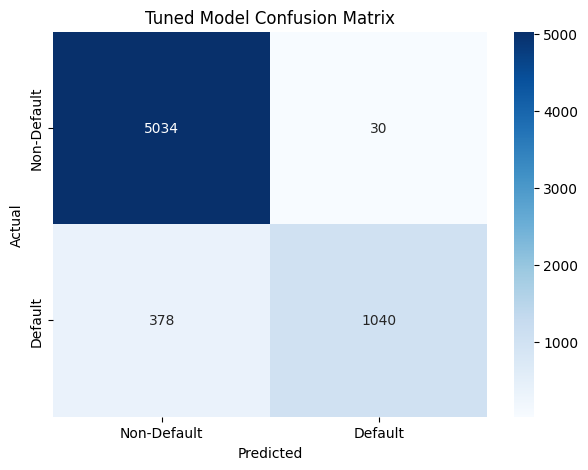

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Default", "Default"],
    yticklabels=["Non-Default", "Default"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Model Confusion Matrix")

plt.show()

In [19]:
joblib.dump(
    tuned_model,
    "../model/credit_risk_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [20]:
results_df.to_csv(
    "../model/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [21]:
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"Initial best model: {best_model_name}")

print("\nBest parameters:")
print(grid_search.best_params_)

print("\nFinal test performance:")

for metric, value in tuned_results.items():
    print(f"{metric}: {value:.4f}")

print("\nFiles created:")
print("1. ../model/credit_risk_model.pkl")
print("2. ../model/model_comparison.csv")

FINAL MODEL SUMMARY
Initial best model: XGBoost

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}

Final test performance:
Accuracy: 0.9371
Precision: 0.9720
Recall: 0.7334
F1 Score: 0.8360
ROC-AUC: 0.9470
PR-AUC: 0.9031

Files created:
1. ../model/credit_risk_model.pkl
2. ../model/model_comparison.csv
